In [75]:
%matplotlib widget
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm
from numba import njit
import matplotlib.animation as animation
from matplotlib.widgets import Slider

In [76]:
@njit
def apply_noise(psi, p):
    flip = np.random.rand(*psi.shape) < p
    return np.where(flip, -psi, psi)

@njit
def s_ij(psi_m, psi_p):
        return psi_m*psi_p

### Zero Temperature Glauber

In [80]:

@njit
def Glauber_sweep(psi): 
        J=1
        #whole lattice update (but individual sites still selected probabilistically)
        L = psi.shape[0]
        DE = 0
        for _ in range(L*L): #random sequential update rule as opposed to a systematic sweep ensuring every site is covered. 
            i = np.random.randint(0,L)
            j = np.random.randint(0,L)
            
            DE = 0
            
            #calculate syndromes with nns vertically
            DE += s_ij(psi[i,j], psi[(i+1) % L, j])
            DE += s_ij(psi[i,j], psi[(i-1) % L, j])
            DE += s_ij(psi[i,j], psi[i, (j+1) % L])
            DE += s_ij(psi[i,j], psi[i, (j-1) % L])
            
            DE *= 2*J

            if DE < 0:
                psi[i,j] *= -1
            elif DE ==  0:
                if np.random.rand() < 0.5:
                        psi[i,j] *= -1
        return psi


@njit
def Glauber_sweeps(psi, sweeps):
        for _ in range(sweeps):
                psi = Glauber_sweep(psi)
        return psi

In [117]:
#Now for snapshot simulation
L = 18
J = 1
p_i = 0.5
psi_init = np.ones((L, L), dtype=np.int64)
psi_init = apply_noise(psi_init, p_i)
psi_glauber = psi_init.copy()

In [118]:
max_steps = 200

glauber_history = []
times = []

glauber_history.append(psi_glauber.copy())

for t in tqdm(range(max_steps), desc = "Progression:"):
        psi_glauber = Glauber_sweep(psi_glauber)
        if t % 1  == 0:
                glauber_history.append(psi_glauber.copy())
                times.append(t)

Progression:: 100%|██████████| 200/200 [00:00<00:00, 24222.83it/s]


Text(0.5, 0.98, 'Glauber vs Toom (p = 0.5)')

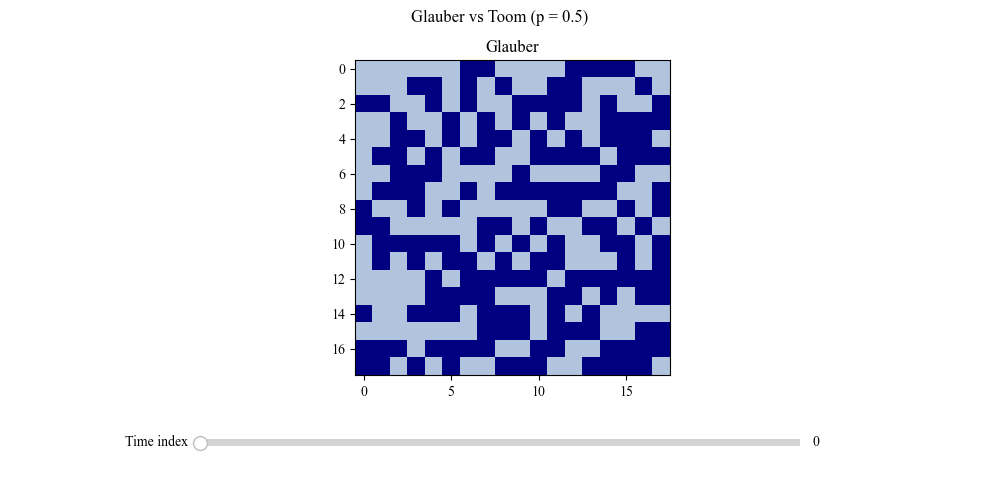

In [119]:
#Plotting, attempting an interactive/dynamic plot
fig, axes = plt.subplots(1, 1, figsize=(10,5))
ax_g = axes

plt.subplots_adjust(bottom = 0.25)
cmap = ListedColormap(["navy","lightsteelblue"])

im_g = ax_g.imshow(glauber_history[0], cmap=cmap, vmin=-1, vmax=1)

title_g = ax_g.set_title("")

def update_plot(idx):
    snap_g = glauber_history[idx]
    
    im_g.set_data(snap_g)
    
    m_g = np.sum(snap_g) / (L * L)
    
    title_g.set_text(f"Glauber t={times[idx]}, m={m_g:.2f}")
    
    ax_g.set_title("Glauber")
    
    fig.canvas.draw_idle()

# Slider axis
ax_slider = plt.axes([0.2, 0.1, 0.6, 0.03])
slider = Slider(ax_slider, 'Time index', 0, 200, valinit=0, valstep=1)

def on_slider(val):
    update_plot(int(slider.val))

def save_gif(glauber_history, toom_history, filename="compare.gif", interval=200):
    fig, axes = plt.subplots(1,2)
    cmap = ListedColormap(["black", "white"])

    im_g = axes[0].imshow(glauber_history[0], cmap=cmap, vmin=-1, vmax=1)
    
    axes[0].axis("off")
    axes[1].axis("off")

    def update(frame):
        im_g.set_array(glauber_history[frame])
        im.set_array(snapshots[frame])
        return [im_g]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(glauber_history),
        interval=interval,
        blit=True
    )

    ani.save(filename, writer='pillow')
    plt.close(fig)

    print(f"Saved GIF as {filename}")

slider.on_changed(on_slider)

# initialize display
update_plot(0)

plt.suptitle(f"Glauber vs Toom (p = {p_i})")

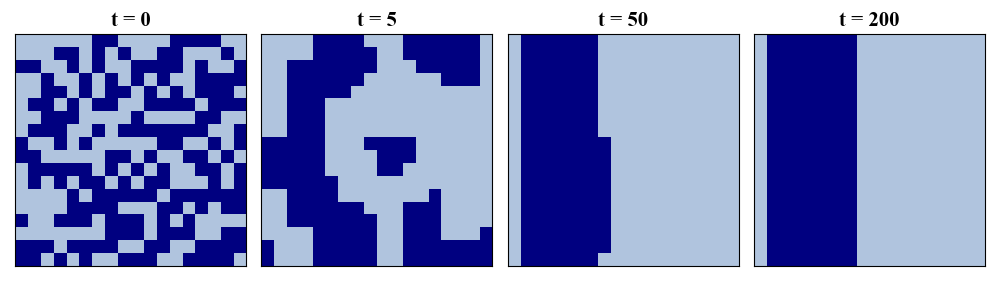

In [139]:
fig, axes = plt.subplots(1, 4, figsize=(10,3))
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

im1,im2,im3, im4 = axes
im1.imshow(glauber_history[0], cmap=cmap, vmin=-1, vmax=1)
im1.set_title("t = 0", fontsize=15, fontweight='bold')
im2.imshow(glauber_history[5], cmap=cmap, vmin=-1, vmax=1)
im2.set_title("t = 5", fontsize=15, fontweight='bold')
im3.imshow(glauber_history[50], cmap=cmap, vmin=-1, vmax=1)
im3.set_title("t = 50", fontsize=15, fontweight='bold')
im4.imshow(glauber_history[200], cmap=cmap, vmin=-1, vmax=1)
im4.set_title("t = 200", fontsize=15, fontweight='bold')
for ax in axes:
    #ax.set_xticks(np.arange(glauber_history[0].shape[1]))
    #ax.set_yticks(np.arange(glauber_history[0].shape[0]))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
plt.tight_layout()
plt.savefig("GlaubSeqpL18Stripe.pdf", pad_inches=0)

### Testing for threshold

In [23]:
@njit
def FullEvolution(L,pnoise, T, J): #kind of similar to a previous function but useful because I initialize new state every time, also only T added not noise
    max_sweeps = 30000 #100*L*L #reconsider
    glauber_steps = 0
    psi_i = np.ones((L, L), dtype=np.int64)
    #print("initial state", psi_i)
    psi_i = apply_noise(psi_i,pnoise)
    #print("initial state", psi_i)
    psi_G = psi_i.copy()
    for t in range(max_sweeps): #doing in different loops so I can individually break them 
        psi_G = Glauber_sweep(psi_G, J)
        glauber_steps += 1
        if np.abs(np.sum(psi_G)) == L*L:
            break
    m_G = np.sum(psi_G)/(L*L)
    return psi_G

In [24]:
state = FullEvolution(10,0.1,0,1)
print(np.sum(state)/(10*10))

1.0


## Noise Dependence

In [25]:
def Noise_analysis(L_arr, p_arr):
    J = 1
    Tn = 0.0
    trials = 1000 
    flogical_arr = {L: [] for L in L_arr}
    fconv_arr = {L: [] for L in L_arr}
    SE_arr = {L: [] for L in L_arr}

    for L_i in L_arr:
        for p_i in p_arr:
            logical_fail = 0 
            convergence_fail = 0
            for _ in tqdm(range(trials), desc=f"L={L_i}, p={p_i:.2f}"):
                state_f = FullEvolution(L_i, p_i, Tn, J)
                if np.sum(state_f)/(L_i*L_i) != 1:
                    logical_fail  += 1
                if abs(np.sum(state_f))/(L_i*L_i) != 1:
                    convergence_fail +=1
            lfp = logical_fail/trials 
            cfp = convergence_fail/trials
            SE = np.sqrt(lfp*(1-lfp)/trials)
            flogical_arr[L_i].append(lfp)
            SE_arr[L_i].append(SE)
            fconv_arr[L_i].append(cfp)
    return flogical_arr, SE_arr, fconv_arr

In [26]:
#Search Parameters and Arrays
L_arr = [5,10]
p_arr = np.linspace(0.3,0.7, 20)

In [27]:
flogical_arr, SE_arr, fconv_arr = Noise_analysis(L_arr, p_arr)

L=10, p=0.70: 100%|██████████| 1000/1000 [00:05<00:00, 175.36it/s]


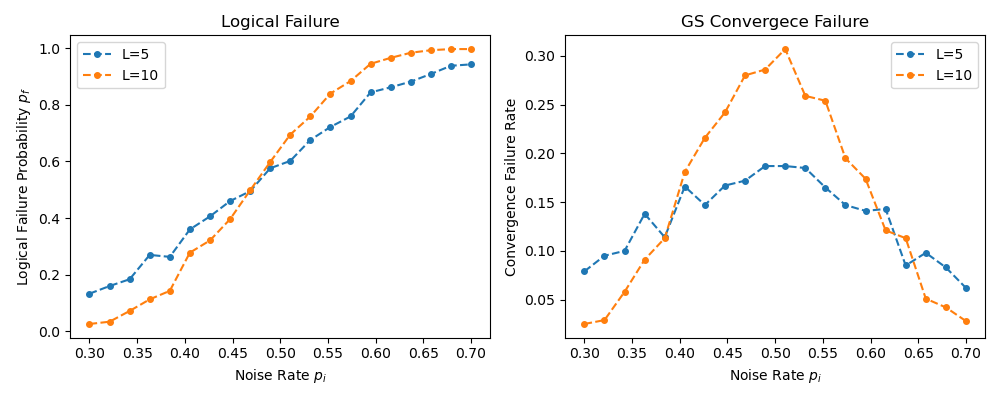

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
for L in L_arr:
    ax1.plot(p_arr, flogical_arr[L], linestyle='--', marker = 'o', markersize=4, label = f"L={L}")
    ax2.plot(p_arr, fconv_arr[L], linestyle='--', marker = 'o', markersize=4, label = f"L={L}")
    
ax1.set_title("Logical Failure")
ax1.set_xlabel("Noise Rate $p_i$")
ax1.set_ylabel("Logical Failure Probability $p_f$")

ax2.set_title("GS Convergece Failure")
ax2.set_xlabel("Noise Rate $p_i$")
ax2.set_ylabel("Convergence Failure Rate")

ax1.legend()
ax2.legend()

plt.savefig('2DIsingIm1.png') 

plt.tight_layout() 

plt.show()

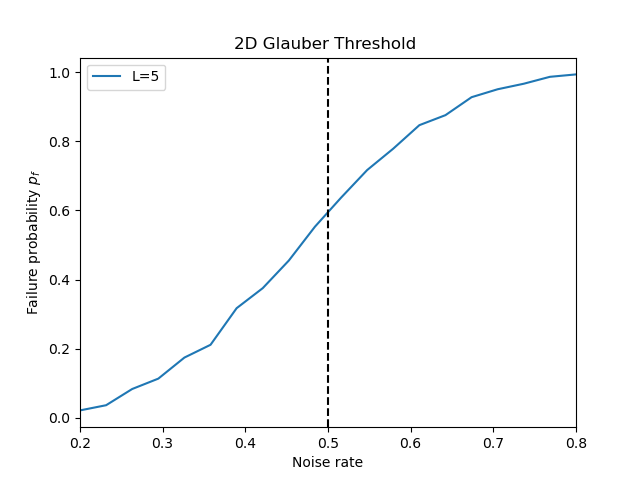

In [15]:
#NOISE DEPENDENCE PLOT
plt.figure()
plt.title("2D Glauber Threshold ")
for L in L_arr:
    plt.plot(p_arr, flogical_arr[L], label = f"L={L}")
plt.legend()
plt.xlabel("Noise rate")
plt.axvline(x=0.5, color='black', linestyle='--')
plt.ylabel("Failure probability $p_f$")
plt.xlim(0.2,0.8)
plt.savefig("2DGlauberThreshold.png")
plt.show()
#I think the threshold is slightly lower now because of the very very slight temperature dependence, 

ValueError: Shape of array too small to calculate a numerical gradient, at least (edge_order + 1) elements are required.

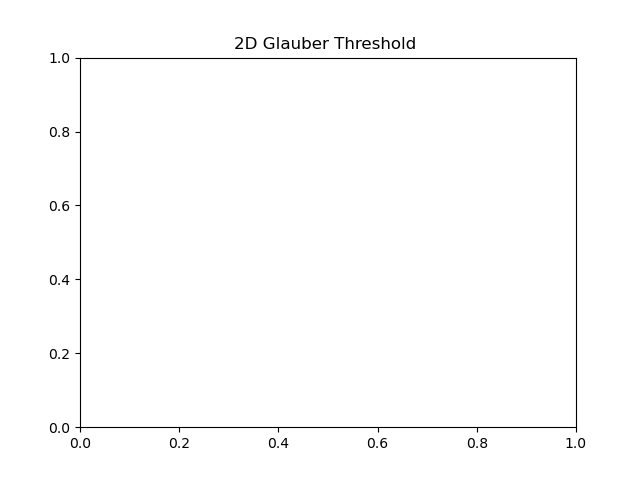

In [39]:
#NOISE DEPENDENCE PLOT
plt.figure()
plt.title("2D Glauber Threshold ")
for L in L_arr:
    plt.plot(p_arr, np.gradient(np.gradient(resultsGp[L])), label = f"L={L}")
plt.legend()
plt.xlabel("Noise rate")
plt.axvline(x=0.5, color='black', linestyle='--')
plt.ylabel("Failure probability $p_f$")
plt.xlim(0.2,0.8)
plt.show()
#I think the threshold is slightly lower now because of the very very slight temperature dependence, 

#### Length vs Failure Probability for fixed P

In [30]:
#Fixed Temperature and Hamiltonian Parameters
J = 1
Tn = 0.0

#Search Parameters and Arrays
L_arr = [5,10, 15,20,30,40]
pf_arr = []
p_arr = [0.2, 0.3, 0.4]
FP_p= {p: [] for p in p_arr}
trials = 300 

#Search
for p_i in p_arr:
    for L_i in L_arr:
        fails_G = 0 
        total_G_steps = 0 
        for _ in tqdm(range(trials), desc=f"L={L_i}, p={p_i:.2f}"):
            mf_G, G_steps = FullEvolutionGT(L_i,Tn,p_i,J)
            total_G_steps += G_steps
            if mf_G != 1: #convergence to +1 zero temperature state
                fails_G += 1
        pf_G = fails_G/trials
        av_G_steps = total_G_steps/trials
        pf_arr.append(pf_G)
        FP_p[p_i].append(pf_G)

L=40, p=0.40: 100%|██████████| 300/300 [00:01<00:00, 159.40it/s]


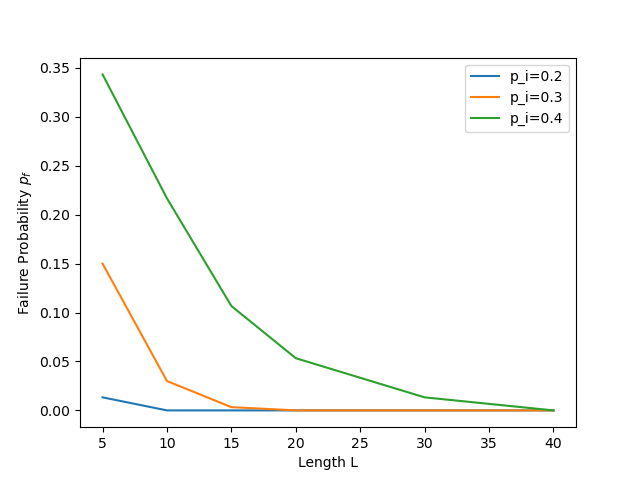

In [37]:
plt.figure()
for p_i in p_arr:
    plt.plot(L_arr, FP_p[p_i], label = f"p_i={p_i}")
plt.legend()
plt.xlabel("Length L")
plt.ylabel("Failure Probability $p_f$")
plt.savefig("2DGlLvpf(ph).png")
plt.show()